# Exploration of funding data

## Imports and settings

In [230]:
import pandas as pd
import numpy as np
import janitor
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
# from wbpyplot import wb_plot

# sns.set_style("white")
sns.set_theme("notebook")

## Reading in 2022-23 data 

In [231]:
fsf_raw = pd.read_excel("../data/raw/fy23-local-law-16-final-report.xlsx").clean_names()
pta_raw = pd.read_excel(
    "../data/raw/2022-23-pta-financial-reporting.xlsx", 
    sheet_name = "School"
).clean_names()
nyc_transparency_raw = pd.read_excel(
    "../data/raw/NewYorkCitySchoolTransparency202223.xlsx", 
    sheet_name = "Part C",
    skiprows=6
).clean_names()
demographics_raw = pd.read_excel(
    "../data/raw/demographic-snapshot-2020-21-to-2024-25-public.xlsx", 
    sheet_name = "School"
).clean_names()

## Viewing and exploring data 

### Fair student funding  

In [232]:
fsf_raw.head()
fsf_raw.describe()
fsf_raw["district"].value_counts()

district
02             119
10              85
31              75
09              70
27              64
11              62
97              61
24              57
19              52
30              52
08              51
28              51
15              50
17              49
12              47
25              47
29              47
06              46
20              46
03              44
07              41
13              41
21              41
22              41
14              38
26              34
18              33
04              29
05              28
23              28
32              27
01              26
16              23
79               4
Grand Total      1
Name: count, dtype: int64

### PTA fundraising 

In [233]:
pta_raw.head()
pta_raw.describe()

,beginning_balance,total_income,total_expenses,ending_balance
count,1.103000e+03,1.102000e+03,1.081000e+03,1.103000e+03
mean,3.861643e+04,4.449220e+04,4.395723e+04,3.535862e+04
std,1.823018e+05,1.505614e+05,2.746530e+05,1.252470e+05
min,-2.131300e+02,0.000000e+00,0.000000e+00,-7.972000e+01
25%,0.000000e+00,0.000000e+00,0.000000e+00,1.020000e+02
50%,2.321000e+03,3.744380e+03,2.541000e+03,2.490420e+03
75%,1.223480e+04,2.824904e+04,2.137845e+04,1.259506e+04
max,4.430494e+06,1.913576e+06,6.434385e+06,1.809919e+06


### NYCPS funding transparency 

In [234]:
nyc_transparency_raw.head()
nyc_transparency_raw.describe()

,classroom_teachers,all_other_salaries,employee_benefits,boces_services,all_other,total_allocation_by_object,general_ed_\nk_12,pre_k,special_ed_\nk_12,preschool,...,pupil\nsupport\nservices,total_allocation_by_purpose,state_&_local_funding,federal_\nfunding,total_funding_source_by_school,state_&_local\nfunding_per_pupil,federal_funding_\nper_pupil,central_district_costs,total_school_allocation_w_central_district_costs,total_school_funding_per_pupil
count,1.610000e+03,1.610000e+03,1.610000e+03,1610.0,1.610000e+03,1.610000e+03,1.610000e+03,1.610000e+03,1.610000e+03,1.610000e+03,...,1.610000e+03,1.610000e+03,1.610000e+03,1.610000e+03,1.610000e+03,1609.000000,1609.000000,1.610000e+03,1.610000e+03,1609.000000
mean,8.737884e+06,5.329085e+06,7.142046e+06,0.0,7.024351e+05,2.191145e+07,1.046600e+07,7.237410e+05,7.376614e+06,3.149619e+05,...,1.500010e+06,2.191145e+07,2.003506e+07,1.876392e+06,2.191145e+07,22037.748039,2321.963953,9.863306e+06,3.177476e+07,33978.171849
std,1.752228e+08,1.068737e+08,1.432217e+08,0.0,1.408902e+07,4.393954e+08,2.098918e+08,1.457410e+07,1.480063e+08,6.339749e+06,...,3.008061e+07,4.393954e+08,4.017749e+08,3.762766e+07,4.393954e+08,13519.903161,1845.727216,1.978050e+08,6.371871e+08,14277.053466
min,4.461100e+05,3.123720e+05,4.303941e+05,0.0,1.000000e+03,1.323262e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,1.323262e+06,1.257372e+06,0.000000e+00,1.323262e+06,10618.726926,0.000000,5.386338e+05,1.900370e+06,20315.665516
25%,2.480107e+06,1.541900e+06,2.083961e+06,0.0,9.342425e+04,6.452414e+06,2.913759e+06,0.000000e+00,1.492713e+06,0.000000e+00,...,4.700780e+05,6.452414e+06,5.741230e+06,5.247381e+05,6.452414e+06,16325.171263,1255.888874,2.657100e+06,9.277115e+06,27575.706624
50%,3.500356e+06,2.068258e+06,2.811638e+06,0.0,2.290875e+05,8.692771e+06,4.274114e+06,0.000000e+00,2.375046e+06,0.000000e+00,...,6.405500e+05,8.692771e+06,7.825685e+06,8.014145e+05,8.692771e+06,18878.023372,2017.592857,3.948378e+06,1.279188e+07,30941.079937
75%,5.201871e+06,2.845078e+06,4.075885e+06,0.0,5.095002e+05,1.244674e+07,6.100747e+06,5.050742e+05,3.750299e+06,1.967770e+05,...,9.142209e+05,1.244674e+07,1.135850e+07,1.157914e+06,1.244674e+07,22867.416667,2930.644901,5.691724e+06,1.848907e+07,35696.681265
max,7.033996e+09,4.289913e+09,5.749347e+09,0.0,5.654603e+08,1.763872e+10,8.425129e+09,5.826115e+08,5.938175e+09,2.535443e+08,...,1.207508e+09,1.763872e+10,1.612822e+10,1.510496e+09,1.763872e+10,292813.419162,42540.101796,7.939962e+09,2.557868e+10,344971.980816


### Demographic snapshot

In [235]:
demographics_raw.head()

,dbn,school_name,year,total_enrollment,grade_3k,grade_pk_half_day_&_full_day_,grade_k,grade_1,grade_2,grade_3,...,%_white,#_missing_race_ethnicity_data,%_missing_race_ethnicity_data,#_students_with_disabilities,%_students_with_disabilities,#_english_language_learners,%_english_language_learners,#_poverty,%_poverty,economic_need_index
0,01M015,P.S. 015 Roberto Clemente,2020-21,193,0,17,29,29,27,30,...,0.056995,0,0.0,44,0.227979,21,0.108808,161,0.834197,0.864466
1,01M015,P.S. 015 Roberto Clemente,2021-22,179,0,15,30,26,24,22,...,0.067039,0,0.0,45,0.251397,11,0.061453,150,0.837989,0.879354
2,01M015,P.S. 015 Roberto Clemente,2022-23,180,0,11,35,32,22,27,...,0.077778,0,0.0,49,0.272222,12,0.066667,152,0.844444,0.862961
3,01M015,P.S. 015 Roberto Clemente,2023-24,189,0,17,29,35,25,30,...,0.047619,0,0.0,45,0.238095,24,0.126984,164,0.867725,0.873524
4,01M015,P.S. 015 Roberto Clemente,2024-25,159,0,7,21,27,30,23,...,0.031447,0,0.0,40,0.251572,11,0.069182,145,0.91195,0.917736


## Cleaning and processing data

In [236]:
fsf_data = fsf_raw.rename(
    columns=lambda x:x.lower().replace("%","p")
).rename(
    columns={
        "total_fsf_allocation_including_foundation_and_collective_bargaining_costs" : "total_fsf",
        "total_fsf_allocation_at_100p_including_foundation_&_adjusted_for_collective_bargaining_costs" : "total_fsf_at_100"
    }
)

pta_data = pta_raw

nyc_transparency_data = nyc_transparency_raw.rename(
    columns=lambda x:x.lower().replace("&","and")
)

demographics_data = demographics_raw.rename(
    columns=lambda x:x.lower().replace("%","p")
).rename(
    columns=lambda x:x.lower().replace("#","n")
).query(
    "year == '2022-23'"
).assign(
    eni_n = lambda x: np.where(x["economic_need_index"] == "Above 95%", 0.95, x["economic_need_index"])
)

### Merge FSF, PTA, and demographics data

In [237]:
# limit sample to schools in District 1-32 
fsf_data = fsf_data.assign(
    district_n = pd.to_numeric(fsf_data["district"], errors="coerce")
).query(
    "district_n >= 1 and district_n <= 32"
)

In [238]:
# merge on school ID 
funding_data = fsf_data.merge(
    pta_data, 
    left_on = "dbn", 
    right_on = "dbn",
    how = "outer",
    indicator = True
)

# view merge results
funding_data["_merge"].value_counts()

# keep if in both 
funding_data = funding_data[funding_data["_merge"] == "both"]

# merge in demographics 
funding_data = funding_data.merge(
    demographics_data, 
    left_on = "dbn",
    right_on = "dbn",
    how = "inner"
)

### Create per-pupil values

In [239]:
funding_data = funding_data.assign(
    pp_fsf = lambda x: x['total_fsf'] / x['total_enrollment'],
    pp_non_fsf = lambda x: x['non_fsf_budget_allocations'] / x['total_enrollment'],
    pp_total = lambda x: x['total_budget_allocation'] / x['total_enrollment'],
    pp_pta_end_balance = lambda x: x['ending_balance'] / x['total_enrollment'],
)

# log transform PTA end balance and take care of the 2 negative values
funding_data['log_pp_pta_end_balance'] = np.log(funding_data['pp_pta_end_balance'] + np.abs(np.min(active_ptas["pp_pta_end_balance"])) + 0.1)

funding_data["pp_pta_end_balance"].describe()

count    1055.000000
mean       68.130414
std       241.833349
min        -0.229741
25%         0.315461
50%         5.807687
75%        23.353246
max      3562.831949
Name: pp_pta_end_balance, dtype: float64

In [240]:
# look outlier school with >$3500 per-pupil PTA balance 
funding_data.query("pp_pta_end_balance > 3500")

,district,dbn,school_name_x,school_type,weighted_register_allocation,weighted_register_allocation_if_fsf_fully_funded,weighted_register_allocation_gap_to_100p,p_funded,foundation_\n_not_included_in_the_funding_p_,collective_bargaining_for_school_based_staff_not_included_in_the_funding_p_,...,p_english_language_learners,n_poverty,p_poverty,economic_need_index,eni_n,pp_fsf,pp_non_fsf,pp_total,pp_pta_end_balance,log_pp_pta_end_balance
154,03,03M334,The Anderson School,K-8 School,3.602414e+06,3.602414e+06,0.0,1.0,333803.330509,995865.889101,...,0.001969,51,0.100394,0.144106,0.144106,9708.82611,1629.955561,11338.781671,3562.831949,8.178404


### More data exploration

<Axes: xlabel='log_pp_pta_end_balance', ylabel='Count'>

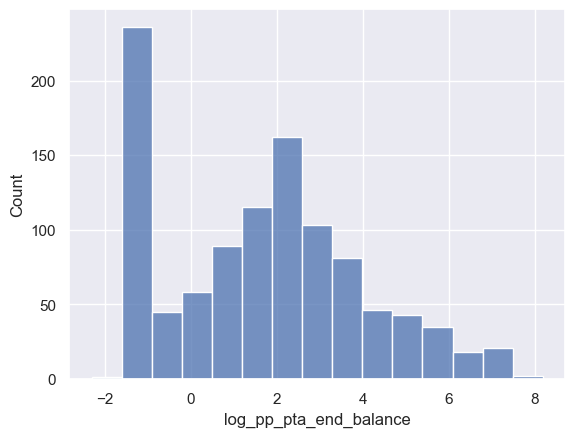

In [241]:
# histogram of PTA end balances 
len(funding_data.query("pp_pta_end_balance>100"))

sns.histplot(
    # data = funding_data.query("pp_pta_end_balance>100"),
    data = funding_data,
    x = "log_pp_pta_end_balance"
)

In [242]:
# how many have missing or inactive PTAs?
missing_ptas = funding_data.query("ending_balance.isnull()")
inactive_ptas = funding_data.query("total_income == 0 and beginning_balance == 0")
active_ptas = funding_data.query("ending_balance.notnull() and total_income != 0 and beginning_balance != 0")

In [243]:
print(f"There are {len(missing_ptas)} schools missing PTA data,\n\
    {len(inactive_ptas)} schools with 0 PTA income and balance, and\n\
    {len(active_ptas)} schools with active PTAs.\n")


print(f"The mean ENI for schools missing PTA data is {np.mean(missing_ptas["eni_n"]):.2f},\n\
    the mean ENI for schools with inactive PTAs is {np.mean(inactive_ptas["eni_n"]):.2f}, and\n\
    the mean ENI for schools with active PTA data is {np.mean(active_ptas["eni_n"]):.2f}.\n")

There are 408 schools missing PTA data,
    213 schools with 0 PTA income and balance, and
    711 schools with active PTAs.

The mean ENI for schools missing PTA data is 0.78,
    the mean ENI for schools with inactive PTAs is 0.90, and
    the mean ENI for schools with active PTA data is 0.68.



<Axes: xlabel='log_pp_pta_end_balance', ylabel='Count'>

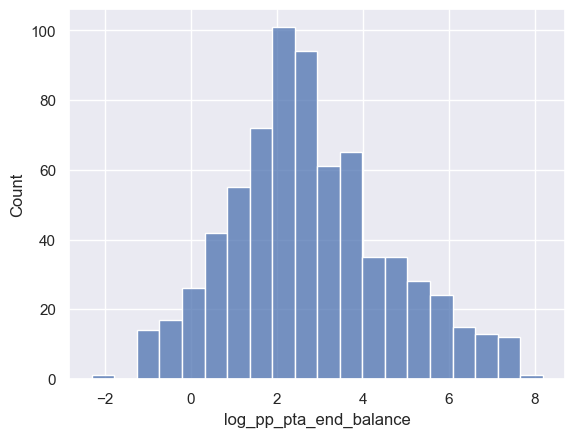

In [244]:
sns.histplot(
    data = active_ptas,
    x = "log_pp_pta_end_balance"
)

## Explore public vs. PTA funding relationship

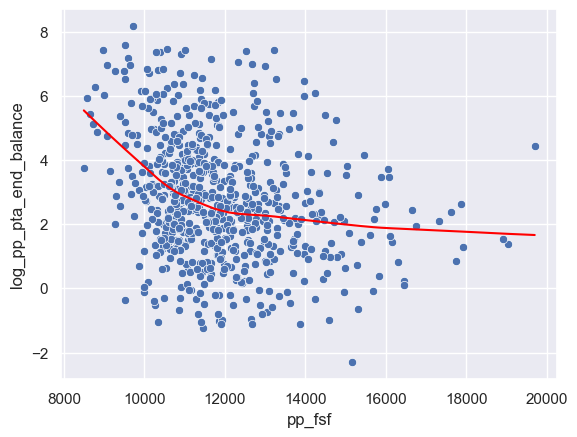

In [ ]:
sns.scatterplot(
    data = active_ptas,
    x = "pp_fsf",
    y = "log_pp_pta_end_balance"
)

# add LOESS line
smoothed = sm.nonparametric.lowess(
    endog = active_ptas["log_pp_pta_end_balance"],
    exog = active_ptas["pp_fsf"]
)
plt.plot(smoothed[:, 0], smoothed[:, 1], color='red')


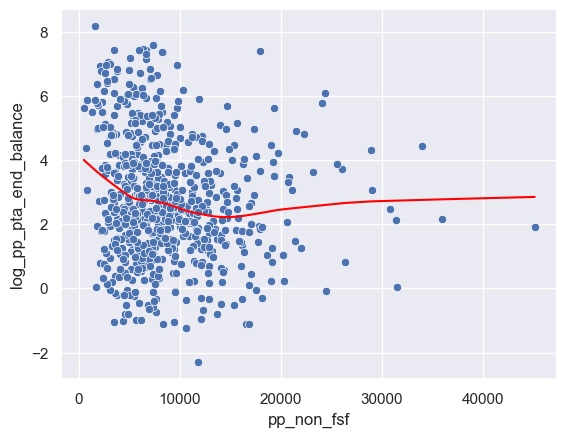

In [252]:
sns.scatterplot(
    data = active_ptas,
    x = "pp_non_fsf",
    y = "log_pp_pta_end_balance"
)

# add LOESS line
smoothed = sm.nonparametric.lowess(
    endog = active_ptas["log_pp_pta_end_balance"],
    exog = active_ptas["pp_non_fsf"]
)
plt.plot(smoothed[:, 0], smoothed[:, 1], color='red')

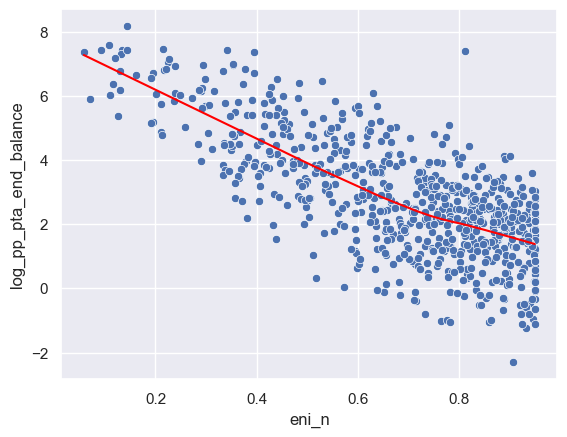

In [253]:
sns.scatterplot(
    data = active_ptas,
    x = "eni_n",
    y = "log_pp_pta_end_balance"
)
# add LOESS line
smoothed = sm.nonparametric.lowess(
    endog = active_ptas["log_pp_pta_end_balance"],
    exog = active_ptas["eni_n"]
)
plt.plot(smoothed[:, 0], smoothed[:, 1], color='red')


np.float64(0.40932625132633)

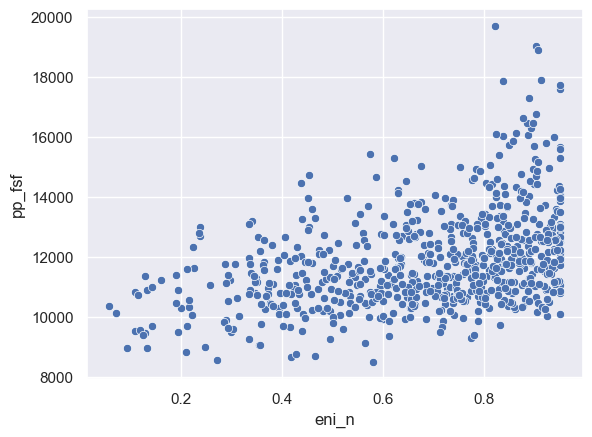

In [228]:
# investigate correlation between FSF and ENI
sns.scatterplot(
    data = active_ptas,
    x = "eni_n",
    y = "pp_fsf"
)

active_ptas["pp_fsf"].corr(active_ptas["eni_n"])